# Part 5 — Clinical Trial Simulation Pipeline

This notebook demonstrates the **complete simulation pipeline** from drug rule-set generation to patient-level daily simulation, CRF mapping, and statistical validation.

## Pipeline Overview
```
Drug Name + Indication
        │
        ▼
┌─ Phase 0: Rule Set Generation ─────────────────────┐
│  Evidence Collection (10+ biomedical DBs)           │
│  → LLM Synthesis (Gemini 2.0 Flash, 3 stages)      │
│  → Rule Set (JSON): AE profile, regimen, efficacy   │
│  → Validation (schema + hallucination checks)       │
└─────────────────────────────────────────────────────┘
        │
        ▼
┌─ Phase 1: Patient Generation ───────────────────────┐
│  Demographics sampling (code)                       │
│  → Comorbidity adjustment (LLM)                     │
│  → Baseline labs/vitals (LLM)                       │
│  → Persona generation (LLM)                         │
└─────────────────────────────────────────────────────┘
        │
        ▼
┌─ Phase 2: Daily Simulation (Day 1 → 126) ──────────┐
│  Hazard functions (AE onset/resolution/grade)       │
│  Ornstein-Uhlenbeck process (labs/vitals continuity)│
│  AE-Lab causal model (AE → lab shift)               │
│  Tumor response (sigmoid model)                     │
│  LLM enrichment on event days only                  │
└─────────────────────────────────────────────────────┘
        │
        ▼
┌─ Validation & Output ───────────────────────────────┐
│  CRF Mapping (→ CDASH domains)                      │
│  Rule Set comparison (SMD / TOST / chi-square)      │
│  CSR Statistics (ICH E3 compliant)                  │
└─────────────────────────────────────────────────────┘
```

---

This notebook is part of the **MedGemma Clinical Trial Engine** pipeline:

```
Part 1  Visual AE Detection ─── MedGemma 1.5 + MedSigLIP (image → AE classification)
Part 2  Cough Detection ──────── HeAR + 2-Stage Classifier (audio → cough type)
Part 3  Care AI Conversation ── MedGemma-4B as virtual nurse (multi-turn dialogue → AE detection)
    ↓
Part 4  Rule Set Generation ─── 10 biomedical DBs → LLM synthesis → simulation parameters
Part 5  Simulation Pipeline ─── Hazard functions + LLM enrichment → synthetic clinical trial data
    ↓
Part 6  Anti-Hallucination ──── RLFR fine-tuning to reduce fabrication in medical text
Part 7  Doc Agent ──────────────  CRF data → MedWatch 3500A pharmacovigilance reports
```


**Runtime:** ~5-10 minutes (10 patients × 126 days)  
**LLM:** Google Gemini 2.0 Flash (no MedGemma needed)  
**Zero hardcoding:** Change the drug name and everything adapts.

---
## 0. Setup

In [ ]:
# Run once to install dependencies
!pip install -q google-genai openai pydantic pydantic-settings httpx requests aiohttp numpy pandas matplotlib nest-asyncio jsonschema python-dotenv

In [1]:
import os, sys, json, time, asyncio
from pathlib import Path
from datetime import datetime
from IPython.display import display, Markdown, HTML
import warnings
warnings.filterwarnings('ignore')

try:
    import nest_asyncio
    nest_asyncio.apply()
except ImportError:
    pass  # will fall back to new event loop if needed

ROOT = Path('/data2/workspace/ClinicalTrialEngine')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / 'src' / 'ruleset_generation'))

# Load .env if present
env_path = ROOT / '.env'
if env_path.exists():
    for line in env_path.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith('#') and '=' in line:
            k, v = line.split('=', 1)
            os.environ.setdefault(k.strip(), v.strip())

assert os.environ.get('GOOGLE_API_KEY'), 'GOOGLE_API_KEY not set — create .env with GOOGLE_API_KEY=...'
os.environ.setdefault('RULE_ENGINE_LLM_API_KEY', os.environ['GOOGLE_API_KEY'])

def run_async(coro):
    """Run an async coroutine from sync context, handling Jupyter's running loop."""
    try:
        loop = asyncio.get_running_loop()
        return loop.run_until_complete(coro)
    except RuntimeError:
        return asyncio.run(coro)

print(f'Root: {ROOT}')
print(f'API key: ...{os.environ["GOOGLE_API_KEY"][-6:]}')
print(f'Time: {datetime.now().strftime("%Y-%m-%d %H:%M")}')

Root: /data2/workspace/ClinicalTrialEngine
API key: ...R5Kzco
Time: 2026-02-23 08:13


In [2]:
# ── Configuration ──
DRUG_NAME   = 'Etoposide + Cisplatin'
INDICATION  = 'extensive-stage small cell lung cancer'
N_PATIENTS  = 10
TOTAL_DAYS  = 126
MAX_WORKERS = 10
MODEL       = 'gemini-2.0-flash'

RUN_NAME = f'{datetime.now().strftime("%Y%m%d_%H%M%S")}_{DRUG_NAME.replace(" ", "_")}_{N_PATIENTS}pt_{TOTAL_DAYS}d'
RUN_DIR  = ROOT / 'data' / 'runs' / RUN_NAME

print(f'Drug:       {DRUG_NAME}')
print(f'Indication: {INDICATION}')
print(f'Patients:   {N_PATIENTS} × {TOTAL_DAYS} days')
print(f'Run dir:    {RUN_DIR}')

Drug:       Etoposide + Cisplatin
Indication: extensive-stage small cell lung cancer
Patients:   10 × 126 days
Run dir:    /data2/workspace/ClinicalTrialEngine/data/runs/20260223_081333_Etoposide_+_Cisplatin_10pt_126d


---
## 1. Phase 0 — Rule Set Generation

The Rule Set Generation Pipeline collects evidence from **10+ biomedical databases** (OpenFDA, DailyMed, ClinicalTrials.gov, PubMed, ChEMBL, PrimeKG, ONSIDES, etc.) and synthesizes them into a structured rule set using a **3-stage LLM pipeline**.

In [3]:
from rule_engine.config import RuleEngineConfig
from rule_engine.evidence.collector import collect_evidence
from rule_engine.converter import convert_ruleset, split_base_overlay
from rule_engine.schema import RuleSet

drugs = [d.strip() for d in DRUG_NAME.split('+')]
config = RuleEngineConfig(multi_stage=True)

print(f'Collecting evidence for: {drugs} / {INDICATION}')
print('Databases queried: DailyMed, OpenFDA, ClinicalTrials.gov, PubMed, ChEMBL, PrimeKG, ONSIDES, DrugBank, PubChem, MeSH, PDS\n')

t0 = time.time()
bundle = run_async(collect_evidence(drugs, INDICATION, config))
elapsed_ev = time.time() - t0
print(f'\n--- Evidence collected in {elapsed_ev:.1f}s ---')

# Per-drug evidence sources
for drug, sde in bundle.per_drug.items():
    sources_found = []
    if sde.dailymed.found: sources_found.append(f'DailyMed ({len(sde.dailymed.ae_table)} AEs)')
    if sde.openfda.total_ae_reports > 0: sources_found.append(f'OpenFDA ({sde.openfda.total_ae_reports} reports)')
    if sde.chembl.has_data: sources_found.append('ChEMBL')
    if sde.drugbank.found: sources_found.append('DrugBank')
    if sde.pubchem.found: sources_found.append('PubChem')
    if sde.onsides.found: sources_found.append(f'ONSIDES ({len(sde.onsides.ae_pairs)} pairs)')
    print(f'  {drug}: {", ".join(sources_found) or "no data"}')

# Shared evidence
shared = []
if bundle.clinical_trials.trial_count > 0: shared.append(f'ClinicalTrials.gov ({bundle.clinical_trials.trial_count} trials)')
if bundle.combo_trials.trial_count > 0: shared.append(f'Combo trials ({bundle.combo_trials.trial_count})')
if bundle.literature.article_count > 0: shared.append(f'PubMed ({bundle.literature.article_count} articles)')
if bundle.primekg.found: shared.append('PrimeKG')
if bundle.mesh.found: shared.append(f'MeSH ({bundle.mesh.disease_mesh_name})')
if bundle.pds.found: shared.append(f'PDS (n={bundle.pds.safety_population_n})')
print(f'  Shared: {", ".join(shared) or "none"}')

PrimeKG files not found: nodes=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/nodes_exhaustion_augmented.csv edges=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/edges_exhaustion_augmented.csv


PrimeKG files not found: nodes=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/nodes_exhaustion_augmented.csv edges=/data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/primekg/edges_exhaustion_augmented.csv


Databases queried: DailyMed, OpenFDA, ClinicalTrials.gov, PubMed, ChEMBL, PrimeKG, ONSIDES, DrugBank, PubChem, MeSH, PDS



DrugBank vocabulary not found: /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/drugbank/drugbank_vocabulary.csv


DrugBank vocabulary not found: /data2/workspace/ClinicalTrialEngine/src/ruleset_generation/data/drugbank/drugbank_vocabulary.csv



--- Evidence collected in 6.1s ---
  Etoposide: DailyMed (0 AEs), OpenFDA (128693 reports), ChEMBL, PubChem
  Cisplatin: DailyMed (0 AEs), OpenFDA (137584 reports), ChEMBL, PubChem
  Shared: ClinicalTrials.gov (100 trials), Combo trials (50), PubMed (633 articles)


In [4]:
# LLM Synthesis (multi-stage: 5 parallel extractions → grounding → assembly)
from rule_engine.agent_multistage import synthesize_rules_multistage

t0 = time.time()
rule_set_obj, agent_log = run_async(
    synthesize_rules_multistage(drugs, INDICATION, bundle, config)
)
elapsed_synth = time.time() - t0

print(f'Rule set synthesized in {elapsed_synth:.1f}s')
print(f'LLM stages: {len(agent_log.stage_logs) if agent_log else "?"}')

# Convert to target schema and save
internal = json.loads(rule_set_obj.model_dump_json())
converted, schema_type = convert_ruleset(internal)
base_dict, overlay_dict = split_base_overlay(converted, schema_type)

# Save rule set for orchestrator
rule_set_dir = RUN_DIR / 'rules'
rule_set_dir.mkdir(parents=True, exist_ok=True)
(rule_set_dir / 'base.json').write_text(json.dumps(base_dict, indent=2, ensure_ascii=False))
(rule_set_dir / f'{schema_type}.json').write_text(json.dumps(overlay_dict, indent=2, ensure_ascii=False))

# Merge into single rule_set.json for the orchestrator
rule_set_merged = {**base_dict, **overlay_dict}
rule_set_path = RUN_DIR / 'rule_set.json'
RUN_DIR.mkdir(parents=True, exist_ok=True)
rule_set_path.write_text(json.dumps(rule_set_merged, indent=2, ensure_ascii=False))

print(f'Schema type: {schema_type}')
print(f'Saved to: {rule_set_path}')

Stage 2 grounding failed (non-fatal): Expecting ',' delimiter: line 506 column 6 (char 11463)


Primary parse failed: 17 validation errors for RuleSet
drugs
  Field required [type=missing, input_value={'adverse_events': [{'eve...t_duration_days': None}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
indication
  Field required [type=missing, input_value={'adverse_events': [{'eve...t_duration_days': None}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
phase
  Field required [type=missing, input_value={'adverse_events': [{'eve...t_duration_days': None}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
treatment_duration_days
  Field required [type=missing, input_value={'adverse_events': [{'eve...t_duration_days': None}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/missing
regimen.0.cycle_days
  Input should be a valid integer [type=int_type, input_value=None, input_type=NoneType]
    For further info

Rule set synthesized in 69.6s
LLM stages: 14
Schema type: iv_combination
Saved to: /data2/workspace/ClinicalTrialEngine/data/runs/20260223_081333_Etoposide_+_Cisplatin_10pt_126d/rule_set.json


In [5]:
# Inspect the generated rule set
import pandas as pd

rs = rule_set_merged
print(f'Drug: {rs.get("drug_name", rs.get("drugs"))}')
print(f'Indication: {rs.get("indication")}')
print(f'Regimen cycle: {rs.get("regimen", {}).get("cycle_days", "?")} days')
print(f'Expected ORR: {rs.get("efficacy", {}).get("overall_response_rate", "?")}%')
print(f'Expected median OS: {rs.get("efficacy", {}).get("median_os_months", "?")} months')
print(f'\n── AE Profile (top 15) ──')

ae_profile = rs.get('ae_profile', rs.get('adverse_events', []))
if isinstance(ae_profile, list):
    ae_rows = []
    for ae in ae_profile[:15]:
        name = ae.get('name', ae.get('ae_name', '?'))
        freq = ae.get('frequency_pct', ae.get('overall_frequency_pct', '?'))
        g3 = ae.get('grade3_plus_pct', ae.get('grade_3_4_pct', '?'))
        ae_rows.append({'AE': name, 'All Grades (%)': freq, 'Grade ≥3 (%)': g3})
    display(pd.DataFrame(ae_rows))
else:
    print(json.dumps(ae_profile, indent=2)[:1000])

Drug: Etoposide + Cisplatin
Indication: extensive-stage small cell lung cancer
Regimen cycle: ? days
Expected ORR: 0.742%
Expected median OS: ? months

── AE Profile (top 15) ──


,AE,All Grades (%),Grade ≥3 (%)
0,?,?,?
1,?,?,?
2,?,?,?
3,?,?,?
4,?,?,?
5,?,?,?
6,?,?,?
7,?,?,?
8,?,?,?
9,?,?,?


---
## 2. Rule Set Validation

Two levels of validation:
1. **Schema validation** — structural correctness
2. **Clinical plausibility** — hallucination detection (severity fabrication, onset plausibility, FAERS coverage)

In [6]:
from rule_engine.validator import validate_rule_set

warnings_list = validate_rule_set(rule_set_obj, bundle=bundle)

if warnings_list:
    print(f'⚠ {len(warnings_list)} warnings:')
    for w in warnings_list[:15]:
        print(f'  - {w}')
    if len(warnings_list) > 15:
        print(f'  ... and {len(warnings_list)-15} more')
else:
    print('✅ Rule set passed all validation checks (0 warnings)')

# Schema validation (JSON schema against target format)
try:
    from scripts.validate_target_schema import validate_file, load_schemas
    base_schema, type_schemas = load_schemas()
    errors, detected_type = validate_file(rule_set_dir / 'base.json', base_schema, type_schemas, base_only=True)
    if errors:
        print(f'\n❌ Schema errors ({len(errors)}):')
        for e in errors[:5]:
            print(f'  - {e}')
    else:
        print(f'✅ JSON Schema valid (type: {detected_type or schema_type})')
except Exception as e:
    print(f'JSON schema validation skipped: {e}')

Validation for Etoposide + Cisplatin: 48 items


  - AE name normalized: 'Anaemia' → 'Anemia'


  - AE name normalized: 'White blood cell count decreased' → 'Leukopenia'


  - AE name normalized: 'Anorexia' → 'Appetite Decreased'


  - AE name normalized: 'Diarrhoea' → 'Diarrhea'


...

  - Combo: AE 'Pruritus' had null source_drug — auto-assigned to 'Etoposide'


  - Combo: AE 'Arthralgia' had null source_drug — auto-assigned to 'Etoposide'


  - Combo: AE 'Asthenia' had null source_drug — auto-assigned to 'Etoposide'


⚠ 48 warnings:
  - AE name normalized: 'Anaemia' → 'Anemia'
  - AE name normalized: 'White blood cell count decreased' → 'Leukopenia'
  - AE name normalized: 'Anorexia' → 'Appetite Decreased'
  - AE name normalized: 'Diarrhoea' → 'Diarrhea'
  - AE name normalized: 'Hyponatraemia' → 'Hyponatremia'
  - AE name normalized: 'Paraesthesia' → 'Paresthesia'
  - AE name normalized: 'Lymphocyte count decreased' → 'Lymphopenia'
  - AE name normalized: 'Hypokalaemia' → 'Hypokalemia'
  - AE name normalized: 'Pyrexia' → 'Fever'
  - Auto-corrected sex percentages: 25.8%/7.5% (sum=33.3%) → 77.5%/22.5%
  - Auto-rescaled severity_distribution for 'Diarrhea': sum was 15.9, target 28.3
  - Auto-rescaled severity_distribution for 'Rash': sum was 14.5, target 21.5
  - Auto-populated 2 ae_risk_modifiers for 'diabetes' (diabetic)
  - Combo: AE 'Anemia' had null source_drug — auto-assigned to 'Etoposide'
  - Combo: AE 'Alopecia' had null source_drug — auto-assigned to 'Etoposide'
  ... and 33 more


✅ JSON Schema valid (type: iv_combination)


---
## 3. Phase 1 — Patient Generation

Each patient is generated through a 4-step process:
1. **Demographics** — age, sex, race sampled from rule set distributions
2. **Comorbidities** — LLM adjusts base probabilities given demographics
3. **Baseline values** — LLM generates internally consistent labs/vitals (e.g., CKD → creatinine↑)
4. **Persona** — LLM assigns personality type that determines symptom reporting behavior

In [7]:
from src.orchestrator_v2 import SimulationRunnerV2

runner = SimulationRunnerV2(
    drug_name=DRUG_NAME,
    indication=INDICATION,
    model=MODEL,
    data_dir=str(RUN_DIR),
    seed=42,
)
runner.rule_set = rule_set_merged

print(f'Generating {N_PATIENTS} patients (parallel, {MAX_WORKERS} workers)...')
t0 = time.time()
patients = runner.create_patients_parallel(n=N_PATIENTS, max_workers=MAX_WORKERS)
print(f'\n✅ {len(patients)} patients generated in {time.time()-t0:.1f}s')

Logging initialized → /data2/workspace/ClinicalTrialEngine/logs/sim_20260223_081452.log


Logging initialized → /data2/workspace/ClinicalTrialEngine/logs/sim_20260223_081452_Etoposide_+_Cisplatin_extensive-stage_small_cell_lung_cancer.log


Phase 1: Generating 10 patients (parallel, 10 workers)


[Patient Agent] Generating PT-001 (1/10)...


[Patient Agent] Generating PT-002 (2/10)...


...

  Persona: stoic_minimizer
  Persona: compliant_but_forgetful
  Persona: compliant_but_forgetful


  [LLM #29] patient_agent.PT-008 | gemini-2.0-flash | in=1,883ch out=613ch | 1833ms


  Persona: compliant_but_forgetful


  [LLM #30] patient_agent.PT-006 | gemini-2.0-flash | in=1,849ch out=525ch | 1703ms


  Persona: stoic_minimizer
  10 patients generated in 12.0s (1.2s/patient)

✅ 10 patients generated in 12.0s


In [8]:
# Patient overview
pt_rows = []
for p in patients:
    dm = p.get('emr', {}).get('demographics', {})
    dx = p.get('emr', {}).get('diagnosis', {})
    persona = p.get('persona', {})
    pt_rows.append({
        'ID': p.get('patient_id'),
        'Age': dm.get('age'),
        'Sex': dm.get('sex'),
        'Race': dm.get('race', '')[:15],
        'ECOG': p.get('emr', {}).get('baseline_ecog'),
        'Stage': dx.get('stage', ''),
        'Persona': persona.get('type', ''),
    })
display(pd.DataFrame(pt_rows))

# Inspect one patient's full profile
print(f'\n── Sample patient ({patients[0]["patient_id"]}) baseline labs ──')
labs = patients[0].get('emr', {}).get('baseline_labs', {})
for k, v in list(labs.items())[:10]:
    print(f'  {k}: {v}')

,ID,Age,Sex,Race,ECOG,Stage,Persona
0,PT-001,68,Male,Not Hispanic,1,IV,stoic_minimizer
1,PT-002,36,Female,Not Hispanic,0,IV,catastrophizer
2,PT-003,47,Male,Not Hispanic,0,IV,stoic_minimizer
3,PT-004,59,Male,Not Hispanic,0,IV,compliant_but_forgetful
4,PT-005,41,Male,Not Hispanic,1,IV,compliant_but_forgetful
5,PT-006,43,Male,Not Hispanic,2,IV,stoic_minimizer
6,PT-007,61,Male,Not Hispanic,1,IV,confused_elderly
7,PT-008,39,Male,Not Hispanic,1,IV,compliant_but_forgetful
8,PT-009,50,Male,Not Hispanic,0,IV,stoic_minimizer
9,PT-010,53,Male,Not Hispanic,2,IV,shame_avoidant



── Sample patient (PT-001) baseline labs ──
  _description: Each lab: {value: float, unit: string}. Must be consistent with comorbidities.
  _required_labs: ANC, hemoglobin, platelets, creatinine, eGFR, ALT, AST, total_bilirubin, glucose_fasting, HbA1c, TSH, LDH
  hemoglobin: {'value': 13.5, 'unit': 'g/dL'}
  wbc: {'value': 6.2, 'unit': 'x10^9/L'}
  platelets: {'value': 250, 'unit': 'x10^9/L'}
  anc: {'value': 3.5, 'unit': 'x10^9/L'}
  creatinine: {'value': 95, 'unit': 'umol/L'}
  eGFR: {'value': 80, 'unit': 'mL/min/1.73m^2'}
  ast: {'value': 28, 'unit': 'U/L'}
  alt: {'value': 25, 'unit': 'U/L'}


---
## 4. Phase 2 — Daily Simulation

The daily simulation engine uses **code-based probabilistic models** (not LLM for every day):

| Component | Method | Purpose |
|-----------|--------|---------|
| AE onset/resolution | Hazard functions | When AEs start/stop |
| AE grade transitions | Markov probabilities | Grade worsening/improving |
| Labs & vitals | Ornstein-Uhlenbeck process | Physiological continuity |
| AE → Lab shifts | 3-layer causal model | hepatitis → ALT↑, neutropenia → ANC↓ |
| Tumor response | Sigmoid model | Tumor shrinkage/growth over time |
| LLM enrichment | Gemini Flash | Event-day narrative & clinical detail |

**LLM is only called on "event days"** (AE onset, grade change, treatment modification) — quiet days are pure code.

In [9]:
print(f'Starting simulation: {N_PATIENTS} patients × {TOTAL_DAYS} days (natural mode)')
print(f'Workers: {MAX_WORKERS}\n')

t0 = time.time()
all_results = runner.run_parallel(
    patients, total_days=TOTAL_DAYS, mode='natural', max_workers=MAX_WORKERS, save=True
)
sim_elapsed = time.time() - t0

print(f'\n✅ Simulation complete in {sim_elapsed:.1f}s ({sim_elapsed/N_PATIENTS:.1f}s/patient)')
print(f'Total days simulated: {sum(len(v) for v in all_results.values())}')

[DailySimulator] Initializing for PT-001


[DailySimulator] Initializing for PT-002


[DailySimulator] Initializing for PT-003


[DailySimulator] Initializing for PT-004


[DailySimulator] Initializing for PT-005


...

  [LLM #343] daily_agent | gemini-2.0-flash | in=25,111ch out=2,015ch | 5123ms


  [LLM #344] daily_agent | gemini-2.0-flash | in=16,292ch out=2,000ch | 5815ms


  PT-009: 127 days, AEs: none, ECOG: 0


  [LLM #345] daily_agent | gemini-2.0-flash | in=27,140ch out=2,046ch | 5982ms


  ✖ Deceased on Day 92
  PT-002: 93 days, AEs: ['alopecia'], ECOG: 1

  ✅ natural simulation complete: 10 patients in 248.1s (24.8s/patient)

✅ Simulation complete in 248.1s (24.8s/patient)
Total days simulated: 1126


---
## 5. Simulation Output Exploration

Let's inspect what the simulation produced — day-by-day patient data including labs, vitals, AEs, and tumor response.

In [10]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.facecolor'] = '#0d1117'
matplotlib.rcParams['axes.facecolor'] = '#161b22'
matplotlib.rcParams['text.color'] = '#e6edf3'
matplotlib.rcParams['axes.labelcolor'] = '#8b949e'
matplotlib.rcParams['xtick.color'] = '#8b949e'
matplotlib.rcParams['ytick.color'] = '#8b949e'

# Load simulation data for first patient
pid = patients[0]['patient_id']
sim_file = RUN_DIR / 'simulations' / f'{pid}_natural.jsonl'
days_data = []
with open(sim_file) as f:
    for line in f:
        days_data.append(json.loads(line))

print(f'Patient {pid}: {len(days_data)} days of data')
print(f'\n── Day 1 snapshot ──')
d1 = days_data[0] if days_data else {}
obj = d1.get('objective', {})
print(f'  Location: {obj.get("location")}')
print(f'  Treatment: {obj.get("treatment_status")}')
print(f'  ECOG: {obj.get("ecog")}')
print(f'  Active AEs: {len(obj.get("active_aes", []))}')

# Find a day with AEs
ae_days = [d for d in days_data if d.get('objective', {}).get('active_aes')]
if ae_days:
    sample = ae_days[min(3, len(ae_days)-1)]
    print(f'\n── Day {sample["day"]} (with AEs) ──')
    for ae in sample['objective']['active_aes']:
        print(f'  {ae.get("ae", "?")}: Grade {ae.get("grade")}, onset Day {ae.get("onset_day")}')

Patient PT-001: 127 days of data

── Day 1 snapshot ──
  Location: OUTPATIENT
  Treatment: screening
  ECOG: 1
  Active AEs: 0


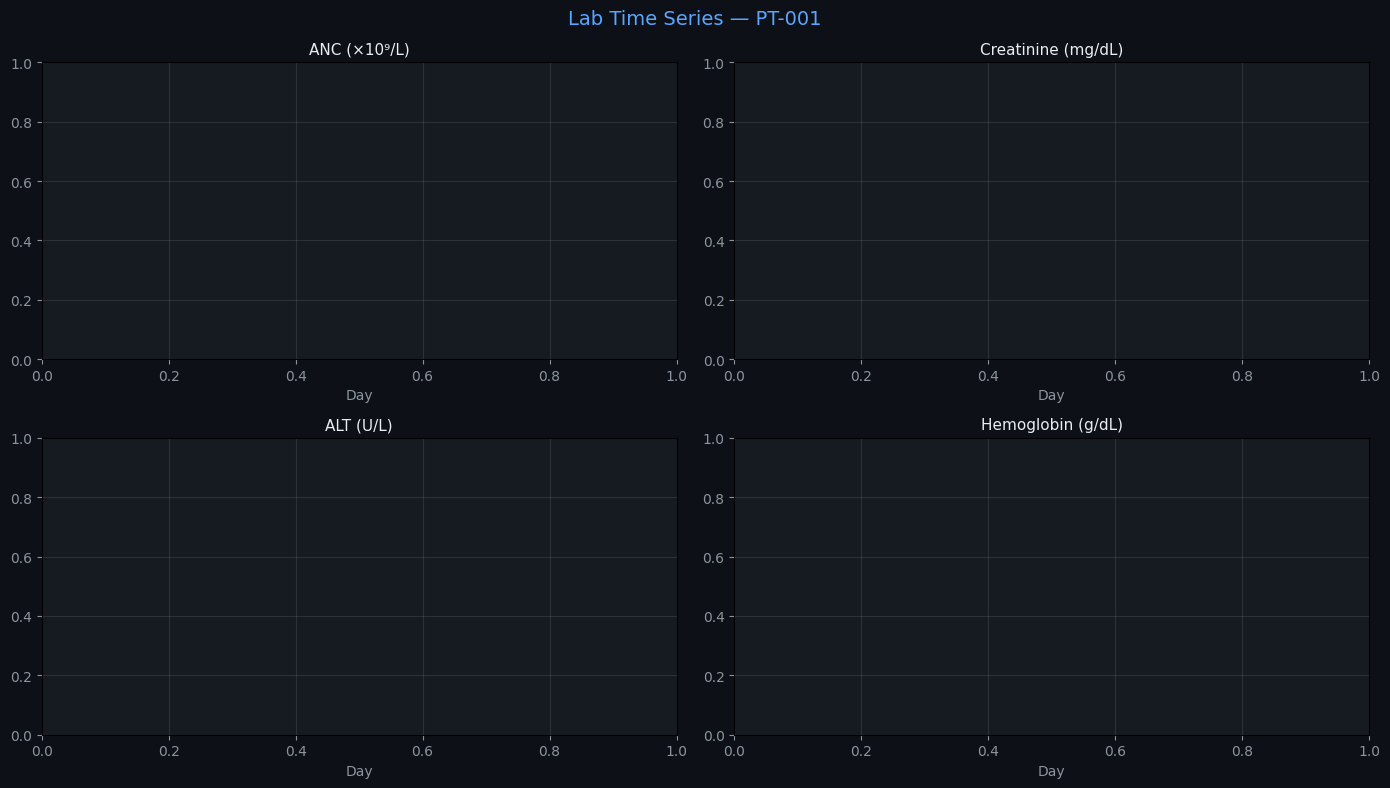

In [11]:
# Lab time series — demonstrates Ornstein-Uhlenbeck continuity + AE-Lab causal model
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle(f'Lab Time Series — {pid}', fontsize=14, color='#58a6ff')

lab_keys = [('ANC', 'ANC (×10⁹/L)'), ('creatinine', 'Creatinine (mg/dL)'),
            ('ALT', 'ALT (U/L)'), ('hemoglobin', 'Hemoglobin (g/dL)')]

for ax, (key, label) in zip(axes.flat, lab_keys):
    day_nums, values = [], []
    for d in days_data:
        labs = d.get('objective', {}).get('labs', {}) or d.get('LB', {})
        if not labs:
            continue
        val = None
        for lk, lv in labs.items():
            if key.lower() in lk.lower():
                val = lv.get('value', lv) if isinstance(lv, dict) else lv
                break
        if val is not None:
            try:
                day_nums.append(d['day'])
                values.append(float(val))
            except (ValueError, TypeError):
                pass
    if values:
        ax.plot(day_nums, values, color='#39d2c0', linewidth=1.2, alpha=0.9)
        ax.fill_between(day_nums, values, alpha=0.1, color='#39d2c0')
    ax.set_title(label, fontsize=11, color='#e6edf3')
    ax.set_xlabel('Day')
    ax.grid(alpha=0.15)

plt.tight_layout()
plt.show()

In [12]:
# AE Timeline Heatmap — all patients
all_ae_events = []
for pid_key, results in all_results.items():
    for d in results:
        for ae in d.get('objective', {}).get('active_aes', []):
            all_ae_events.append({
                'patient': pid_key, 'day': d['day'],
                'ae': ae.get('ae', '?'), 'grade': ae.get('grade', 1)
            })

if all_ae_events:
    ae_df = pd.DataFrame(all_ae_events)
    ae_counts = ae_df.groupby('ae').agg(patients=('patient', 'nunique'), events=('day', 'count')).sort_values('patients', ascending=False)
    print(f'Total AE events: {len(ae_df)}, unique terms: {ae_df["ae"].nunique()}')
    display(ae_counts.head(15))
else:
    print('No AEs recorded (possible with very short simulations)')

Total AE events: 3232, unique terms: 32


,patients,events
ae,,
fatigue,8,220
alopecia,7,438
anaemia,7,235
weight_decreased,7,164
vomiting,6,59
dyspnoea_nos,6,199
anorexia,5,116
hypoalbuminaemia,5,142
nausea,5,59


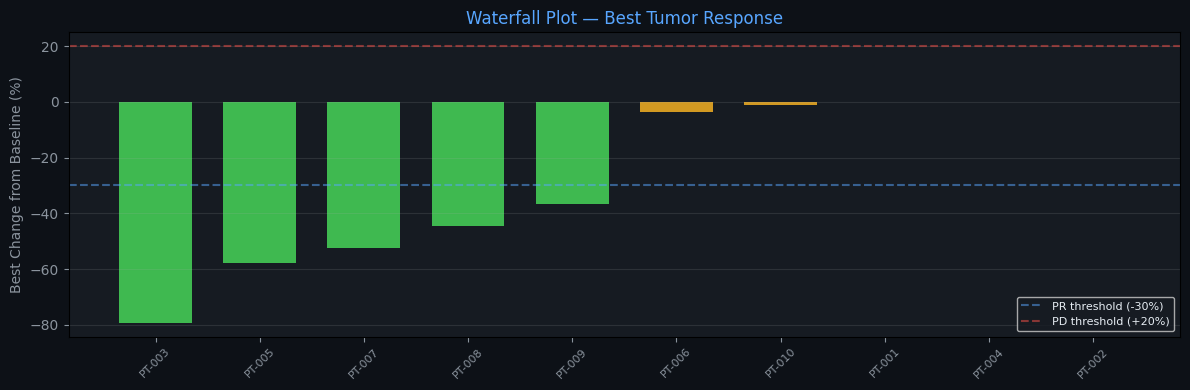

In [13]:
# Waterfall Plot — Best Tumor Response
waterfall = []
for pid_key, results in all_results.items():
    best = None
    for d in results:
        tumor = d.get('objective', {}).get('tumor') or {}
        change = tumor.get('estimated_change_pct')
        if change is not None:
            if best is None or change < best:
                best = change
    if best is not None:
        waterfall.append({'patient': pid_key, 'change': best})

if waterfall:
    wf = sorted(waterfall, key=lambda x: x['change'])
    colors = ['#3fb950' if w['change'] <= -30 else '#d29922' if w['change'] <= 0 else '#f85149' for w in wf]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(range(len(wf)), [w['change'] for w in wf], color=colors, width=0.7)
    ax.axhline(-30, color='#58a6ff', linestyle='--', alpha=0.5, label='PR threshold (-30%)')
    ax.axhline(20, color='#f85149', linestyle='--', alpha=0.5, label='PD threshold (+20%)')
    ax.set_ylabel('Best Change from Baseline (%)')
    ax.set_title('Waterfall Plot — Best Tumor Response', color='#58a6ff')
    ax.set_xticks(range(len(wf)))
    ax.set_xticklabels([w['patient'] for w in wf], rotation=45, fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.15, axis='y')
    plt.tight_layout()
    plt.show()
else:
    print('No tumor data available')

---
## 6. CRF Mapping — CDASH Conversion

Raw simulation data is mapped to **CDASH-compliant CRF domains**: AE, LB, VS, EC, CM, DS, RS, TU, DD, PE, EG.

In [14]:
from src.crf_mapper import map_day_record, map_patient_record

# Map a sample day record
sample_day = ae_days[0] if ae_days else days_data[5] if len(days_data) > 5 else days_data[0]
mapped = map_day_record(sample_day, patients[0])

print(f'Day {sample_day["day"]} → CDASH domains: {list(mapped.keys())}\n')

# Show AE domain
if mapped.get('AE'):
    print('── AE Domain ──')
    display(pd.DataFrame(mapped['AE'][:5]))

# Show LB domain (labs)
if mapped.get('LB'):
    print('\n── LB Domain (Labs) ──')
    lb_rows = [{'Test': r.get('LBTEST',''), 'Result': r.get('LBORRES',''), 'Unit': r.get('LBORRESU',''), 'Baseline': r.get('LBBLFL','')} for r in mapped['LB'][:8]]
    display(pd.DataFrame(lb_rows))

Day 5 → CDASH domains: ['patient_id', 'day', 'cycle', 'cycle_day', 'AE', 'EC', 'CM', 'VS', 'LB', 'DS', 'RS', 'TU', 'DD', 'PE', 'EG', 'objective', 'subjective', '_sim', 'care_record', 'hospital_record', 'observation_events', 'mood_state']



---
## 7. Validation — Simulation vs Rule Set

Statistical comparison of simulated data against the generated rule set using **SMD, TOST equivalence tests, and chi-square tests**.

In [15]:
from validation.extract_sim_stats import extract_all_stats

sim_stats = extract_all_stats(str(RUN_DIR), mode='natural')

print('── Extracted Statistics ──')
print(f'Demographics: {list(sim_stats.get("demographics", {}).keys())}')
print(f'AE terms: {len(sim_stats.get("ae_statistics", {}).get("by_term", {}))}')
print(f'Efficacy ORR: {sim_stats.get("efficacy", {}).get("orr_pct", "?")}%')

Loading profiles from /data2/workspace/ClinicalTrialEngine/data/runs/20260223_081333_Etoposide_+_Cisplatin_10pt_126d/patients...
  → 10 patients
Loading simulations (mode=natural)...


  → 10 patients with simulation data
Extracting demographics...
Extracting AE statistics...
Extracting treatment exposure...
Extracting efficacy...
Extracting lab abnormalities...
── Extracted Statistics ──
Demographics: ['n_patients', 'age_median', 'age_mean', 'age_std', 'age_range', 'sex_male_pct', 'sex_female_pct', 'race', 'ecog_ps', 'bmi_median', 'bmi_mean']
AE terms: 0
Efficacy ORR: 50.0%


In [16]:
# Compare simulated AE rates vs rule set expectations
sim_ae = sim_stats.get('ae_statistics', {}).get('by_term', {})
rule_ae = {}
for ae in ae_profile:
    name = ae.get('name', ae.get('ae_name', '?')).lower().replace(' ', '_')
    rule_ae[name] = ae.get('frequency_pct', ae.get('overall_frequency_pct', 0))

comparison_rows = []
for ae_name, rule_freq in sorted(rule_ae.items(), key=lambda x: -x[1])[:15]:
    sim_freq = 0
    for sk, sv in sim_ae.items():
        if ae_name.replace('_', '') in sk.lower().replace('_', '').replace(' ', ''):
            sim_freq = sv.get('incidence_pct', 0)
            break
    comparison_rows.append({
        'AE': ae_name,
        'Rule Set (%)': rule_freq,
        'Simulated (%)': round(sim_freq, 1),
        'Δ': round(sim_freq - rule_freq, 1),
    })

print('── AE Frequency: Rule Set vs Simulation ──')
display(pd.DataFrame(comparison_rows))

── AE Frequency: Rule Set vs Simulation ──


,AE,Rule Set (%),Simulated (%),Δ
0,?,0,0,0


---
## 8. CSR-Level Statistics (ICH E3)

Comprehensive Clinical Study Report statistics — the same tables displayed on the web frontend's Statistical Analysis page.

In [17]:
from validation.csr_stats import compute_csr_stats

csr = compute_csr_stats(str(RUN_DIR), mode='natural')

# Disposition
disp = csr['disposition']
print(f'── Disposition (N={disp["enrolled"]}) ──')
print(f'  Completed: {disp["completed"]["n"]} ({disp["completed"]["pct"]}%)')
print(f'  Discontinued: {disp["discontinued"]["n"]} ({disp["discontinued"]["pct"]}%)')
print(f'  Deaths: {disp["deaths"]["n"]} ({disp["deaths"]["pct"]}%)')

# Efficacy
eff = csr['efficacy']
print(f'\n── Efficacy ──')
print(f'  ORR: {eff["orr"]["pct"]}% (CR={eff["best_response"].get("CR",{}).get("n",0)}, PR={eff["best_response"].get("PR",{}).get("n",0)})')
print(f'  DCR: {eff["dcr"]["pct"]}%')
print(f'  Median OS: {eff["km_os"].get("median", "NR")} days')
print(f'  Median PFS: {eff["km_pfs"].get("median", "NR")} days')

# Safety summary
safe = csr['safety']['summary']
N = csr['safety']['n']
print(f'\n── Safety (N={N}) ──')
print(f'  Any AE: {safe["any_ae"]["n"]}/{N} ({safe["any_ae"]["pct"]}%)')
print(f'  Grade ≥3: {safe["grade_gte3"]["n"]}/{N} ({safe["grade_gte3"]["pct"]}%)')
print(f'  SAE: {safe["sae"]["n"]}/{N} ({safe["sae"]["pct"]}%)')
print(f'  Fatal: {safe["fatal"]["n"]}/{N} ({safe["fatal"]["pct"]}%)')

── Disposition (N=10) ──
  Completed: 7 (70.0%)
  Discontinued: 1 (10.0%)
  Deaths: 2 (20.0%)

── Efficacy ──
  ORR: 50.0% (CR=0, PR=5)
  DCR: 70.0%
  Median OS: None days
  Median PFS: None days

── Safety (N=10) ──
  Any AE: 10/10 (100.0%)
  Grade ≥3: 5/10 (50.0%)
  SAE: 5/10 (50.0%)
  Fatal: 0/10 (0.0%)


In [18]:
# AE by Preferred Term table (CSR Table 14.3.1)
ae_table = csr['safety']['by_term'][:15]
ae_rows = []
for t in ae_table:
    gd = t.get('grade_dist', {})
    ae_rows.append({
        'Preferred Term': t['term'],
        'All Grades n (%)': f"{t['all_grade']['n']} ({t['all_grade']['pct']}%)",
        'Grade ≥3 n (%)': f"{t['grade_gte3']['n']} ({t['grade_gte3']['pct']}%)",
        'G1': gd.get('1', 0), 'G2': gd.get('2', 0),
        'G3': gd.get('3', 0), 'G4': gd.get('4', 0),
        'Median Onset': f"Day {t['onset_median']}" if t.get('onset_median') else '—',
    })

print('── AE by Preferred Term (Top 15) ──')
display(pd.DataFrame(ae_rows))

── AE by Preferred Term (Top 15) ──


,Preferred Term,All Grades n (%),Grade ≥3 n (%),G1,G2,G3,G4,Median Onset
0,fatigue,8 (80.0%),0 (0.0%),7,1,0,0,Day 27.0
1,alopecia,7 (70.0%),0 (0.0%),3,4,0,0,Day 22.0
2,anaemia,7 (70.0%),0 (0.0%),6,1,0,0,Day 22.0
3,weight_decreased,7 (70.0%),0 (0.0%),6,1,0,0,Day 30.0
4,dyspnoea_nos,6 (60.0%),1 (10.0%),3,2,1,0,Day 30.0
5,vomiting,6 (60.0%),0 (0.0%),5,1,0,0,Day 8.0
6,nausea,5 (50.0%),0 (0.0%),5,0,0,0,Day 9.0
7,white_blood_cell_count_decreased,5 (50.0%),0 (0.0%),4,1,0,0,Day 28.0
8,hypoalbuminaemia,5 (50.0%),0 (0.0%),4,1,0,0,Day 36.0
9,vomiting_nos,5 (50.0%),0 (0.0%),5,0,0,0,Day 7.0


In [19]:
# Treatment Exposure
tx = csr['treatment']
print('── Treatment Exposure ──')
print(f'  Duration: {tx["duration"]["mean"]} ± {tx["duration"]["std"]} days (median {tx["duration"]["median"]})')
print(f'  Cycles: {tx["cycles"]["mean"]} ± {tx["cycles"]["std"]} (median {tx["cycles"]["median"]})')
print(f'  Dose reduction: {tx["dose_reduction_all"]["n"]} ({tx["dose_reduction_all"]["pct"]}%)')
print(f'  Dose interruption: {tx["dose_interruption_all"]["n"]} ({tx["dose_interruption_all"]["pct"]}%)')
print(f'  Discontinuation: {tx["discontinuation_all"]["n"]} ({tx["discontinuation_all"]["pct"]}%)')

# Demographics
demo = csr['demographics']
print(f'\n── Demographics ──')
print(f'  Age: {demo["age"]["mean"]} ± {demo["age"]["std"]} (range {demo["age"]["min"]}–{demo["age"]["max"]})')
for sex, info in demo.get('sex', {}).items():
    print(f'  {sex}: {info["n"]} ({info["pct"]}%)')

── Treatment Exposure ──
  Duration: 70.3 ± 43.2 days (median 95.5)
  Cycles: 5.1 ± 1.7 (median 6.0)
  Dose reduction: 1 (10.0%)
  Dose interruption: 3 (30.0%)
  Discontinuation: 1 (10.0%)

── Demographics ──
  Age: 49.7 ± 10.5 (range 36.0–68.0)
  Male: 9 (90.0%)
  Female: 1 (10.0%)


---
## 9. Summary

### Pipeline Recap

In [20]:
total_ae_events = sum(
    sum(1 for d in results for ae in d.get('objective', {}).get('active_aes', []))
    for results in all_results.values()
)
total_days_sim = sum(len(v) for v in all_results.values())

summary = f"""
# Full Pipeline Summary

| Phase | Detail | Time |
|-------|--------|------|
| Drug | **{DRUG_NAME}** ({INDICATION}) | — |
| Rule Set | {len(ae_profile)} AEs, {schema_type} schema | ~2-3 min |
| Validation | {len(warnings_list)} warnings | <1s |
| Patients | **{len(patients)}** generated | ~1-2 min |
| Simulation | **{total_days_sim}** patient-days | {sim_elapsed:.0f}s |
| Total AE events | {total_ae_events} | — |
| ORR | {eff['orr']['pct']}% | — |
| Median OS | {eff['km_os'].get('median', 'NR')} days | — |
| Any AE | {safe['any_ae']['pct']}% | — |
| Grade ≥3 | {safe['grade_gte3']['pct']}% | — |
| LLM | Gemini 2.0 Flash | — |
| Output | `{RUN_DIR.name}` | — |

**Zero hardcoding.** Change `DRUG_NAME` and `INDICATION` at the top to simulate any drug.
"""
display(Markdown(summary))


# Full Pipeline Summary

| Phase | Detail | Time |
|-------|--------|------|
| Drug | **Etoposide + Cisplatin** (extensive-stage small cell lung cancer) | — |
| Rule Set | 35 AEs, iv_combination schema | ~2-3 min |
| Validation | 48 warnings | <1s |
| Patients | **10** generated | ~1-2 min |
| Simulation | **1126** patient-days | 248s |
| Total AE events | 3232 | — |
| ORR | 50.0% | — |
| Median OS | None days | — |
| Any AE | 100.0% | — |
| Grade ≥3 | 50.0% | — |
| LLM | Gemini 2.0 Flash | — |
| Output | `20260223_081333_Etoposide_+_Cisplatin_10pt_126d` | — |

**Zero hardcoding.** Change `DRUG_NAME` and `INDICATION` at the top to simulate any drug.
